# Flood Prediction Module

### The purpose of this notebook is to implement a pertinent detection formula for my prediction module of the FloodWatch application


### Contents:
- [Imports](#p1)
- [Authentication](#p2)
- [Defining the AOI (Area of Interest)](#p3)
- [Configuration](#configuration)

1. [1. Topographic Wetness Index (TWI))](#p4)
    - [Details](#details)
    - [What DEM data could be used](#what-dem-data-could-be-used)
    - [1.1 First Option: MERIT for a and for tan b ](#11-first-option-merit-for-a-and-for-tan-b)
        - [Upslope Contributing Area (per unit contour length)](#upslope-contributing-area-per-unit-contour-length)
        - [Local Slope Gradient](#local-slope-gradient)
        - [Calculate the Topographic Wetness Index (TWI)](#calctwi1)
    - [1.2 The Alternative: MERIT Hydro for a and DEM GLO30 for tan b ](#12-the-alternative-merit-hydro-for-a-and-dem-glo30-for-tan-b)
        - [Process the Copernicus DEM (The Slope)](#process-the-copernicus-dem-the-slope)
        - [Process Flow Accumulation (Upstream Area)](#process-flow-accumulation-upstream-area)
        - [Calculate the Topographic Wetness Index (TWI)](#calctwi2)


### Imports <a id="p1"></a>

In [143]:
import ee
import os
import geemap
import math
import sys
import requests
import time

### Authentication <a id="p2"></a>

In [144]:
print("Authenticating with your personal Google account...")
ee.Authenticate() 
ee.Initialize(project='gen-lang-client-0375557253')

Authenticating with your personal Google account...


### Configuration

In [145]:
# ============================================================
# MASTER CONFIGURATION
# ============================================================
CONFIG = {
    # AOI Parameters
    'city_name': 'Galați',
    'address_type': 'county',
    
    # Time Parameters
    'storm_date': '2024-09-15',
    'api_lookback_days': 30,

}

In [146]:
end = ee.Date(CONFIG['storm_date'])
days = ee.List.sequence(1, CONFIG['api_lookback_days'])  # start from 1, not 0

### Defining the AOI (Area of Interest) <a id="p3"></a>

In [147]:
def get_bbox(city_name  = 'Galati', address_type = 'city'):
    url = f"https://nominatim.openstreetmap.org/search.php?q={city_name}&polygon_geojson=1&format=json"
    
    # Nominatim STRICTLY requires a User-Agent header. 
    # Replace the email with your own to avoid getting blocked.
    headers = {
        'User-Agent': 'FloodWatchApp/1.0 '
    }
    
    for attempt in range(10):
        try:
            response = requests.get(url, headers=headers, timeout=15)
            response.raise_for_status()
            data = response.json()
            
            if not data:
                print(f"No data found for {city_name}")
                return None

            bounding_box = None
            city_data_match = None

            for city_data in data:
                if city_data.get('type') == 'administrative' and city_data.get('addresstype') == address_type:
                    bounding_box = city_data.get('geojson').get('coordinates')
                    city_data_match = city_data
                    break

            geometry_type = city_data_match.get('geojson').get('type')
            
            if geometry_type == 'MultiPolygon':
                return bounding_box[0][0]
            elif geometry_type == 'Polygon':
                return bounding_box[0]

        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(2)
            
    return None

In [148]:
# Define a bounding box
bounding_box = get_bbox(
    city_name=CONFIG['city_name'], 
    address_type=CONFIG['address_type']
)


if bounding_box:
    aoi = ee.Geometry.Polygon([bounding_box])
else:
    aoi = None

if aoi is None:
    print("Failed to retrieve AOI for the given city and address type. Reverting to default bounding box.")
    aoi = ee.Geometry.Polygon([[27.8, 45.3], [28.2, 45.3], [28.2, 45.7], [27.8, 45.7]])

# Initialize the map to check our location
Map = geemap.Map()
Map.centerObject(aoi, zoom=10)
Map.addLayer(ee.Image().paint(aoi, 0, 2), {'palette': 'red'}, "City Boundary")
#Map

# 1. Topographic Wetness Index (TWI) <a id="p4"></a>


### Details <a id="p5"></a>
The Topographic Wetness Index is a terrain analysis metric that predicts how much soil moisture tends to accumulate at any given point in a landscape, based purely on topography.

*In simpler terms: it determines where water is most likely to pool.*

Usefull links:
- https://en.wikipedia.org/wiki/Topographic_wetness_index
- https://www.researchgate.net/publication/313720130_Determination_of_a_topographic_wetness_index_using_high_resolution_digital_elevation_models

The formula:
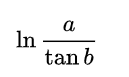
,where a is the local upslope area draining through a certain point per unit contour length and 
b is the local slope in radians.

Or in simpler terms:
- a = the upslope contributing area per unit contour length — essentially, how much water flows toward this point from higher ground
- tan b = the local slope gradient — how steep the terrain is, which determines how fast water drains away

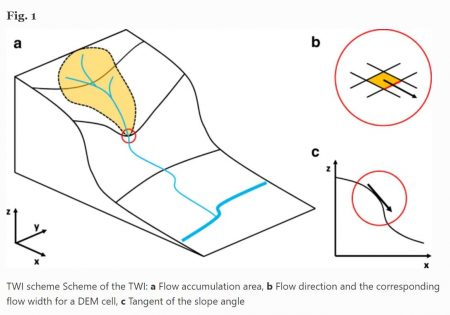

### What DEM data could be used:

The first choice: [Copernicus DEM GLO-30: Global 30m Digital Elevation Model](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_DEM_GLO30)
>Earth Engine snippet: ee.ImageCollection("COPERNICUS/DEM/GLO30")

Pixel size: *30m*

DEM GLO-30 has a great resolution and could prove great value when used in rugged terrain. However it is not hydrologically corrected and it can produce noisy TWI values in flat areas such as the Galati region, due to tiny DEM artefacts inflating or deflating slope estimates.

The second choice: [MERIT Hydro: Global Hydrography Datasets](https://developers.google.com/earth-engine/datasets/catalog/MERIT_Hydro_v1_0_1)
>Earth Engine Snippet: ee.Image("MERIT/Hydro/v1_0_1")

Pixel size: *92.77 meters*

MERIT = Multi-Error-Removed Improved-Terrain

The big advantage is perfect internal consistency — upa(upstream area) and elv(elevation) bands were derived from the same underlying DEM (MERIT-DEM), using the same flow routing algorithm, on the same grid. Another great reason to use them is that elv and upa are hydrologically corrected, working better for flat areas.

For this exact reason I have picked MERIT as my only source of data for this formula. 

## 1.1 First Option: MERIT for a and for tan b 
**This is also the best solution**

In [149]:
merit = ee.Image("MERIT/Hydro/v1_0_1").clip(aoi)

### Upslope Contributing Area (per unit contour length) 

In [150]:
# # Upstream area: km² → m²
# # multiply by 1,000,000 to convert square kilometers to square meters
# up_area = merit.select('upa').multiply(1_000_000)



# # To avoid log(0) errors at the very top of ridges where accumulation is 0
# up_area = up_area.where(up_area.eq(0), 1)


# ## remember that TWI needs specific catchment area: a=A/w, where w is the width of the contour line.
# pixel_size = 92.77   # MERIT pixel resolution
# sca = up_area.divide(pixel_size)

""" --------------------  """
""" D8 flow routing. Each pixel can flow into one of its 8 neighbors, depending on which has the steepest downward slope."""
# Cardinal (dir = 1, 4, 16, 64): L = 92.77
# Diagonal (dir = 2, 8, 32, 128): L = 92.77 / math.sqrt(2) ≈ 65.6

CELL_SIZE_M = 92.77
dir_band = merit.select('dir').toInt()

cardinal = dir_band.remap([1, 4, 16, 64], [1, 1, 1, 1], 0)
diagonal = dir_band.remap([2, 8, 32, 128], [1, 1, 1, 1], 0)

L = (
    cardinal.multiply(CELL_SIZE_M)
    .add(diagonal.multiply(CELL_SIZE_M / math.sqrt(2)))
    .where(cardinal.add(diagonal).eq(0), CELL_SIZE_M)
)

sca = (
    merit.select('upa')
    .multiply(1_000_000)
    .divide(L)
    .max(1)
)

### Local Slope Gradient

In [151]:
# Derive slope from MERIT's own elevation band

slope_deg = ee.Terrain.slope(merit.select('elv'))

# Convert to Radians and prevent division by zero on flat plains
slope_rad = slope_deg.multiply(math.pi / 180.0)
slope_rad = slope_rad.where(slope_rad.eq(0), 0.001)

# Calculate the tangent of the slope: tan(beta)
tan_slope = slope_rad.tan()

### Calculate the Topographic Wetness Index (TWI) <a id="calctwi1"></a>

In [152]:
# Apply the final formula: ln(Upstream Area / tan(Slope))
twi = sca.divide(tan_slope).log()

# Visualize the TWI on the Map
# High TWI values (Blue/Red) mean water pools there. Low values (Grey) mean water drains away.
twi_vis = {
    'min': 5, 
    'max': 18, 
    'palette': ['#d3d3d3', '#add8e6', '#0000ff', '#00008b'] # Grey -> Light Blue -> Blue -> Dark Blue
}

Map.addLayer(twi, twi_vis, 'Topographic Wetness Index (TWI)')



In [153]:
stats = twi.reduceRegion(
    reducer=ee.Reducer.percentile([5, 95]),
    geometry=aoi,
    scale=92,
    maxPixels=1e9
)
print(stats.getInfo())

{'upa_p5': 6.8146170492986435, 'upa_p95': 14.312312313345972}


In [154]:
""" Uncomment this to see the final map """
#Map

' Uncomment this to see the final map '

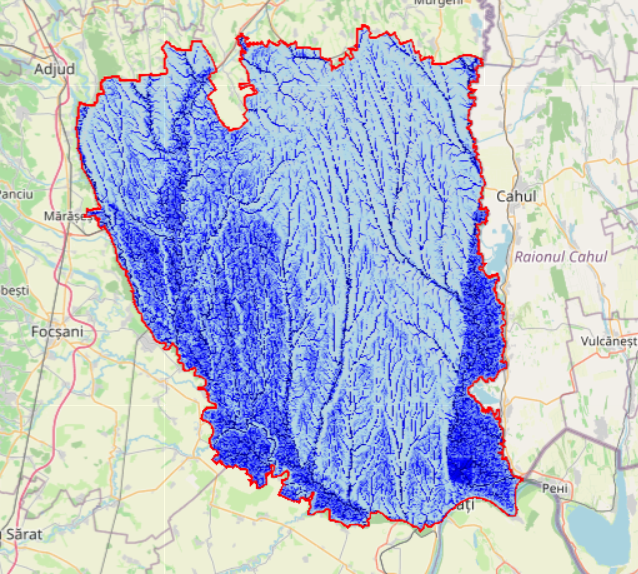

## 1.2 The Alternative: MERIT Hydro for a and DEM GLO30 for tan b 

Copernicus DEM GLO30 for the slope since it has a 30m resolution and the MERIT for upstream area

- tan(b) -> Copernicus 30m for a sharp resolution for the terrain

- a -> MERIT Hydro 90m because tracking the upstream means tracing a river backward hundreds of km making the sharpness unnecessary

In [155]:
Map = geemap.Map()
Map.centerObject(aoi, zoom=10)
Map.addLayer(ee.Image().paint(aoi, 0, 2), {'palette': 'red'}, "City Boundary")

### Process the Copernicus DEM (The Slope)

In [156]:
dem_mosaic = ee.ImageCollection("COPERNICUS/DEM/GLO30") \
    .select('DEM') \
    .mosaic() \
    .setDefaultProjection(crs='EPSG:4326', scale=30) \
    .clip(aoi)

slope_deg = ee.Terrain.slope(dem_mosaic)  # slope in degrees
slope_rad = slope_deg.multiply(math.pi / 180.0)            # convert slope to radians

""" prevent division by zero on perfectly flat water bodies / plains by replacing 0 slope with 0.001  """
slope_rad = slope_rad.where(slope_rad.eq(0), 0.001)

# Calculate tan(b)
tan_slope = slope_rad.tan()

### Process Flow Accumulation (Upstream Area)

In [157]:
# Pull pre-calculated Upstream Catchment Area (in square kilometers)
# We multiply by 1,000,000 to convert square kilometers to square meters
up_area_sq_km = ee.Image("MERIT/Hydro/v1_0_1").select('upa').clip(aoi)
up_area = up_area_sq_km.multiply(1000000)

# To avoid log(0) errors at the very top of ridges where accumulation is 0
up_area = up_area.where(up_area.eq(0), 1)

### Calculate the Topographic Wetness Index (TWI) <a id="calctwi2"></a>

In [158]:

# Apply the final formula: ln(Upstream Area / tan(Slope))
twi = up_area.divide(tan_slope).log()

# Visualize the TWI on the Map
# High TWI values (Blue/Red) mean water pools there. Low values (Grey) mean water drains away.
twi_vis = {
    'min': 5, 
    'max': 20, 
    'palette': ['#d3d3d3', '#add8e6', '#0000ff', '#00008b'] # Grey -> Light Blue -> Blue -> Dark Blue
}


In [159]:
""" Uncomment this to see the final map """
# Map.addLayer(twi, twi_vis, 'Topographic Wetness Index (TWI)')
#Map

' Uncomment this to see the final map '

In [160]:
stats = twi.reduceRegion(
    reducer=ee.Reducer.percentile([5, 95]),
    geometry=aoi,
    scale=92,
    maxPixels=1e9
)
print(stats.getInfo())

{'upa_p5': 10.93931947910468, 'upa_p95': 18.435098928135282}


# 2. Antecedent Precipitation Index (API)

### Details

The Antecedent Precipitation Index (API) is a weighted sum of past daily rainfall used to estimate soil moisture and watershed wetness, with more recent rain weighted higher.

Australian Rainfall and Runoff (Book 5, Section 5.7.4) defines the API for a particular day as:  OR 

The best dataset therefore is CHRIPS since it has a 1 day cadence. This is the best fit for this formula because API is a weighted sum of "daily" rainfall.

In [161]:
DECAY_K = 0.91

In [162]:
def weighted_rain(n):
    n = ee.Number(n)
    date = end.advance(n.multiply(-1), 'day')           #  Aug 16   ->  Sep 14
    rain = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
            .filterDate(date, date.advance(1, 'day'))  
            .filterBounds(aoi)
            .select('precipitation')
            .sum()         # safe against missing dates
            .clip(aoi))
    weight = ee.Number(DECAY_K).pow(n)
    return rain.multiply(weight)

In [163]:
api = (ee.ImageCollection.fromImages(days.map(weighted_rain))
       .sum()
       .rename('API'))

In [164]:
# Visualize
api_vis = {
    'min': 0,
    'max': 100,
    'palette': ['#ffffff', '#add8e6', '#0000ff', '#00008b']
}

Map.addLayer(api, api_vis, 'Antecedent Precipitation Index (API)')

In [165]:
#Map

Antecedent precipitation Index(API) in a dry month  [1st of May 2024 - 1st June 2024]

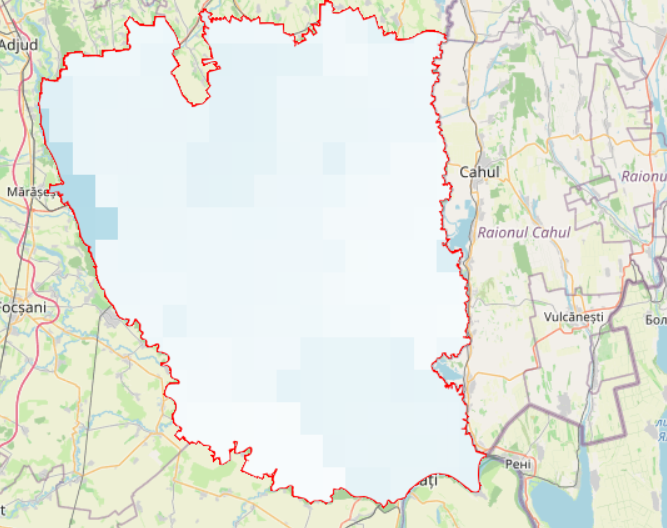

Antecedent precipitation Index(API) when cyclone Boris hit the Galati county [20 August 2024 - 20 September 2024]

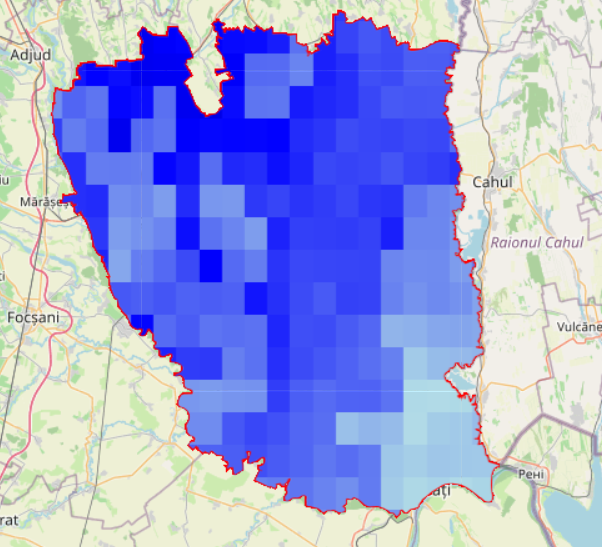

# 3. Runoff Curve Number(CN) or Soil Conservation Service(SCS)

## Details

The SCS Curve Number (CN) method is an empirical, widely used hydrology technique developed by the USDA Soil Conservation Service (now NRCS) to estimate direct runoff from rainfall. The CN value (0–100) reflects land use, soil type, and moisture, determining how much rain infiltrates or runs off.

### Usefull Links:
Wikipedia has very good information on the subject and solid references: [Wikipedia Article](https://en.wikipedia.org/wiki/Runoff_curve_number)

### The equation:
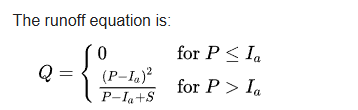, where 
- Q is runoff
- P is rainfall
- Ia is the initial abstraction, generally assumed to be 0.2 S


In [166]:
# Check what dates CORINE actually has
print(ee.ImageCollection('COPERNICUS/CORINE/V20/100m')
      .aggregate_array('system:index')
      .getInfo())

['1990', '2000', '2006', '2012', '2018']


In [167]:
# ═════════════════════════════════════════════════════════════════════════════
# 3. SCS-CN — Curve Number & Runoff Depth
#    Formula: Q = (P − Ia)² / (P − Ia + S)   when P > Ia, else 0
#      S  = 25400/CN − 254  [mm]   potential maximum retention
#      Ia = 0.2 · S          [mm]   initial abstraction
#      P  = storm rainfall   [mm]
#
#    CN depends on:  land cover (CORINE)  ×  hydrologic soil group (SoilGrids)
#    CN is adjusted for antecedent moisture (AMC) using 5-day CHIRPS sum.
# ═════════════════════════════════════════════════════════════════════════════

corine = (ee.Image('COPERNICUS/CORINE/V20/100m/2018')
          .select('landcover')
          .clip(aoi))


#### API — Antecedent Precipitation Index
Formula: API = Σ  k^n · P_{t-n}   for n = 1 … LOOKBACK_DAYS
- k  = decay constant (older rain matters less)
- P  = daily rainfall from CHIRPS

api_5day  — 5-day simple sum       (NRCS TR-55 AMC classification input)


In [168]:

api_5day = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
            .filterDate(end.advance(-5, 'day'), end)        # Sep 10–14
            .filterBounds(aoi)
            .select('precipitation')
            .sum()
            .clip(aoi)
            .rename('API_5day'))

#### Hydrologic Soil Group (HSG)

Derived from SoilGrids clay % (0–30 cm average)
A (<10% clay) → B (10–20%) → C (20–40%) → D (>40%)
HAND override: force Group D where water table is near surface (< 2 m)
This is critical for Galați's Danube floodplain.


In [169]:
clay_pct = (ee.Image('projects/soilgrids-isric/clay_mean')
            .select(['clay_0-5cm_mean', 'clay_5-15cm_mean', 'clay_15-30cm_mean'])
            .reduce(ee.Reducer.mean())
            .divide(10)           # g/kg → %
            .clip(aoi))
 
hsg = (ee.Image(1)
       .where(clay_pct.gte(10), 2)
       .where(clay_pct.gte(20), 3)
       .where(clay_pct.gte(40), 4)
       .where(merit.select('hnd').lt(2), 4)   # high water table → Group D
       .rename('HSG'))


In [170]:
# CN values per CORINE class for each HSG (A, B, C, D)
# Format: corine_code: [CN_A, CN_B, CN_C, CN_D]

CN_TABLE = {
    # Urban fabric
    111: [98, 98, 98, 98],   # continuous urban (fully impervious)
    112: [61, 75, 83, 87],   # discontinuous urban (1/4 acre residential)
    # Industrial, commercial, transport
    121: [81, 88, 91, 93],   # industrial (72% imp.)
    122: [98, 98, 98, 98],   # road/rail (impervious)
    123: [81, 88, 91, 93],   # port areas (industrial)
    124: [89, 92, 94, 95],   # airports (commercial/impervious mix)
    # Mine, dump, construction
    131: [77, 86, 91, 94],   # mineral extraction (newly graded)
    132: [77, 86, 91, 94],   # dump sites (newly graded)
    133: [77, 86, 91, 94],   # construction sites (newly graded)
    # Vegetated artificial
    141: [39, 61, 74, 80],   # green urban (open space good condition)
    142: [49, 69, 79, 84],   # sport/leisure (open space fair)
    # Arable land
    211: [67, 78, 85, 89],   # non-irrigated arable (row crops good)
    212: [67, 78, 85, 89],   # irrigated arable
    213: [67, 78, 85, 89],   # rice fields
    # Permanent crops
    221: [64, 75, 82, 85],   # vineyards (contoured good)
    222: [43, 65, 76, 82],   # fruit trees (orchard fair)
    223: [43, 65, 76, 82],   # olive groves (orchard fair)
    # Pastures
    231: [39, 61, 74, 80],   # pastures good condition
    # Heterogeneous agricultural
    241: [67, 78, 85, 89],   # annual + permanent crops
    242: [67, 78, 85, 89],   # complex cultivation
    243: [58, 72, 81, 85],   # agriculture + natural vegetation
    244: [43, 65, 76, 82],   # agro-forestry
    # Forests
    311: [30, 55, 70, 77],   # broad-leaved forest good
    312: [30, 55, 70, 77],   # coniferous forest good
    313: [30, 55, 70, 77],   # mixed forest good
    # Scrub and herbaceous
    321: [39, 61, 74, 80],   # natural grasslands good
    322: [35, 56, 70, 77],   # moors and heathland fair
    323: [35, 56, 70, 77],   # sclerophyllous vegetation fair
    324: [48, 67, 77, 83],   # transitional woodland-shrub poor
    # Open spaces
    331: [77, 86, 91, 94],   # beaches/dunes (bare)
    332: [77, 86, 91, 94],   # bare rocks
    333: [63, 77, 85, 88],   # sparsely vegetated
    334: [77, 86, 91, 94],   # burnt areas (bare)
    335: [98, 98, 98, 98],   # glaciers (not relevant for Romania)
    # Wetlands — high water table → treat as D regardless
    411: [98, 98, 98, 98],   # inland marshes
    412: [98, 98, 98, 98],   # peat bogs
    421: [98, 98, 98, 98],   # salt marshes
    422: [98, 98, 98, 98],   # salines
    423: [98, 98, 98, 98],   # intertidal flats
    # Water bodies
    511: [100, 100, 100, 100],
    512: [100, 100, 100, 100],
    521: [100, 100, 100, 100],
    522: [100, 100, 100, 100],
    523: [100, 100, 100, 100],
}


codes = list(CN_TABLE.keys())
cn_a  = corine.remap(codes, [CN_TABLE[k][0] for k in codes]).rename('CN')
cn_b  = corine.remap(codes, [CN_TABLE[k][1] for k in codes]).rename('CN')
cn_c  = corine.remap(codes, [CN_TABLE[k][2] for k in codes]).rename('CN')
cn_d  = corine.remap(codes, [CN_TABLE[k][3] for k in codes]).rename('CN')
 
# Select CN image based on HSG
cn = (cn_a
      .where(hsg.eq(2), cn_b)
      .where(hsg.eq(3), cn_c)
      .where(hsg.eq(4), cn_d))

#### AMC adjustment (NRCS table, 5-day antecedent sum)
Thresholds:  <35 mm → AMC I (dry),  >53 mm → AMC III (wet)

In [171]:
cn_ii_vals   = [10,   20,   30,   40,   50,   60,   70,   80,   90,   100]
amc1_factors = [0.40, 0.45, 0.50, 0.55, 0.62, 0.67, 0.73, 0.79, 0.87, 1.00]
amc3_factors = [2.22, 1.85, 1.67, 1.50, 1.40, 1.30, 1.21, 1.14, 1.07, 1.00]
 
cn_rounded = cn.divide(10).round().multiply(10).clamp(10, 100)
cn_dry = cn.multiply(cn_rounded.remap(cn_ii_vals, amc1_factors)).round().clamp(30, 100)
cn_wet = cn.multiply(cn_rounded.remap(cn_ii_vals, amc3_factors)).round().clamp(30, 100)
 
cn_adjusted = (cn
               .where(api_5day.lt(35), cn_dry)   # AMC I  — dry soil
               .where(api_5day.gt(53), cn_wet))   # AMC III — wet soil

#### Runoff Q 

In [172]:
S  = ee.Image(25400).divide(cn_adjusted).subtract(254)   # potential retention (mm)
Ia = S.multiply(0.2)                                     # initial abstraction (mm)

P = (ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
     .filterDate(end, end.advance(1, 'day'))   # Sep 15
     .filterBounds(aoi)
     .select('precipitation')
     .sum()
     .clip(aoi)
     .rename('precipitation'))
 
Q = (P.subtract(Ia).pow(2)
     .divide(P.subtract(Ia).add(S))
     .where(P.lte(Ia), 0)
     .rename('Runoff_mm'))

#### Visualization

In [173]:
Map = geemap.Map()
Map.centerObject(aoi, zoom=9)
 
Map.addLayer(ee.Image().paint(aoi, 0, 2),
             {'palette': 'red'}, 'Galați County')
 
Map.addLayer(twi,
             {'min': 5, 'max': 18,
              'palette': ['#d3d3d3', '#add8e6', '#0000ff', '#00008b']},
             'TWI')
 
Map.addLayer(api,
             {'min': 0, 'max': 100,
              'palette': ['#ffffff', '#add8e6', '#0000ff', '#00008b']},
             'API — 30-day weighted')
 
Map.addLayer(api_5day,
             {'min': 0, 'max': 60,
              'palette': ['#ffffff', '#add8e6', '#0000ff']},
             'API — 5-day sum (AMC input)')
 
Map.addLayer(hsg,
             {'min': 1, 'max': 4,
              'palette': ['#2ecc71', '#f1c40f', '#e67e22', '#c0392b']},
             'Hydrologic Soil Group  (A→D)')
 
Map.addLayer(cn,
             {'min': 30, 'max': 100,
              'palette': ['#2ecc71', '#f1c40f', '#e74c3c']},
             'CN — base (AMC II)')
 
Map.addLayer(cn_adjusted,
             {'min': 30, 'max': 100,
              'palette': ['#2ecc71', '#f1c40f', '#e74c3c']},
             'CN — AMC adjusted')
 
Map.addLayer(P,
             {'min': 0, 'max': 50,
              'palette': ['#ffffff', '#add8e6', '#0000ff']},
             'Storm Rainfall P (mm)')
 
Map.addLayer(Q,
             {'min': 0, 'max': 30,
              'palette': ['#ffffff', '#fdae61', '#d73027', '#4a0026']},
             'Runoff Q (mm)')
 
Map.addLayer(corine, {}, 'CORINE Land Cover 2018', False)
 


In [175]:
Map

Map(center=[45.79220557458316, 27.75643282883871], controls=(WidgetControl(options=['position', 'transparent_b…

#### Diagnostics  (run once to calibrate vis ranges)

In [176]:
layers = {'TWI': twi, 'API': api, 'CN': cn_adjusted, 'Q': Q}
for name, img in layers.items():
    stats = img.reduceRegion(
        reducer=ee.Reducer.percentile([5, 50, 95, 99]),
        geometry=aoi,
        scale=100,
        maxPixels=1e9
    )
    print(f'{name}:', stats.getInfo())
 
# Verify all CORINE classes in AOI are covered by CN_TABLE
unmapped = (corine.remap(codes, codes, -1).eq(-1)
            .selfMask()
            .reduceRegion(ee.Reducer.count(), aoi, 100, maxPixels=1e9))
print('Unmapped CORINE pixels:', unmapped.getInfo())

TWI: {'upa_p5': 10.93934955832692, 'upa_p50': 13.187067416417728, 'upa_p95': 18.435761245718087, 'upa_p99': 22.809201254125178}
API: {'API_p5': 25.886825077238832, 'API_p50': 39.86952819655984, 'API_p95': 52.69485555128564, 'API_p99': 58.44811129633251}
CN: {'CN_p5': 63, 'CN_p50': 84.99999999999996, 'CN_p95': 94.9999999999999, 'CN_p99': 99.99999999999999}
Q: {'Runoff_mm_p5': 0.619510422406853, 'Runoff_mm_p50': 15.370759624519534, 'Runoff_mm_p95': 37.59974222459906, 'Runoff_mm_p99': 47.27088424375306}
Unmapped CORINE pixels: {'remapped': 0}
